#### 2.1 System Analysis  

2.1.1 System zeros: Part I  

Calculte system zero from state space representation without using Control System Toolbox of MATLAB.

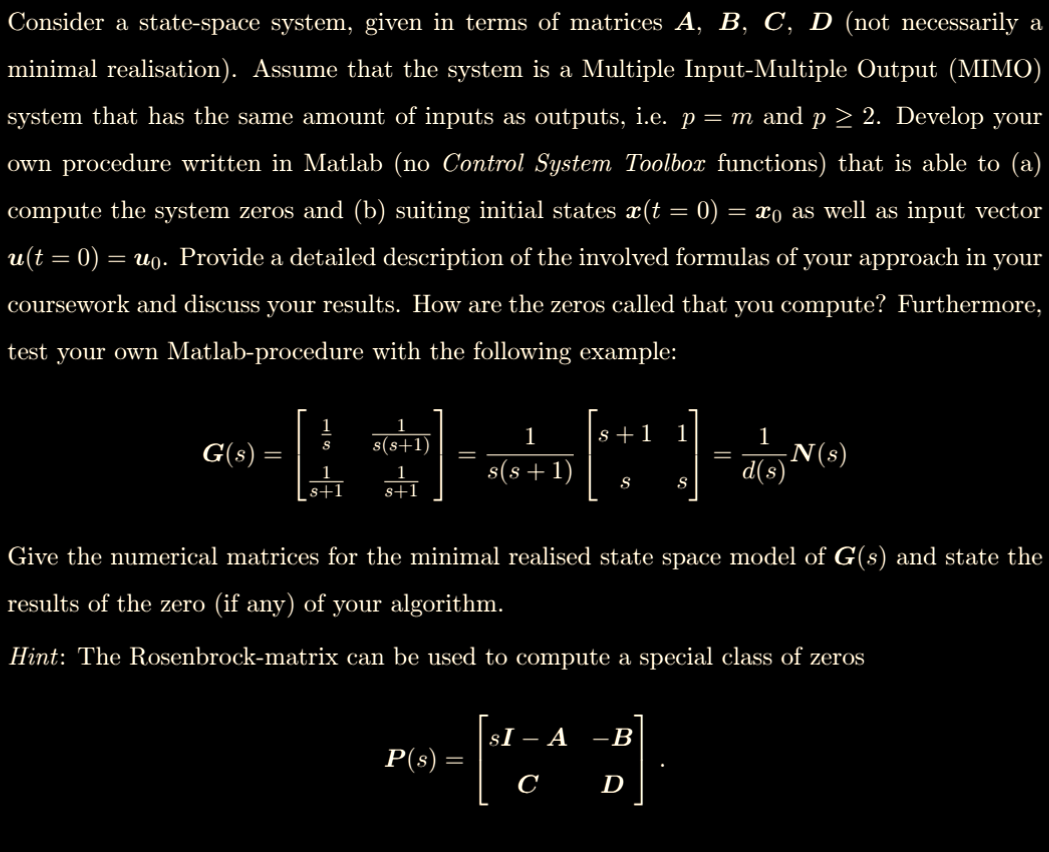

In [2]:
clear all;
% Create a random A, B, C, D 
% input size p and output size m
% from zeros and poles
p = 4; % input size
m = p; % output size
s = tf('s');
sys = rss(6, m, p);
A = sys.A; B = sys.B; C = sys.C; D = sys.D;

In [3]:
getZeros(A, B, C, D) 
% calculated Invariant Zeros

ans = 5×1 double
  -18.1575
   -6.7135
   -3.9472
    0.0316
   11.3150

In [4]:
tzero(sys)

ans = 5×1 double
  -18.1575
   11.3150
   -6.7135
   -3.9472
    0.0316

In [ ]:
% assert getZeros and tzero give same result


In [ ]:
% Example
G = [ (s+2)/(s^2 +3*s +2), 1/(s+1);
      (s+4)/(s^2 +5*s +6), (s+3)/(s+2) ];

sys = ss(G);

In [ ]:
getZeros(sys.A, sys.B, sys.C, sys.D)
tzero(sys)

ans = 5×1 double
   -3.6180
   -2.0000
   -2.0000
   -1.3820
   -1.0000

ans = 5×1 double
   -3.6180
   -1.0000
   -1.3820
   -2.0000
   -2.0000

In [ ]:
sys = minreal(sys);
getZeros(sys.A, sys.B, sys.C, sys.D)
tzero(sys)

3 states removed.


ans = 2×1 double
   -3.6180
   -1.3820

ans = 2×1 double
   -3.6180
   -1.3820

2.1.2 System zeros: Part II

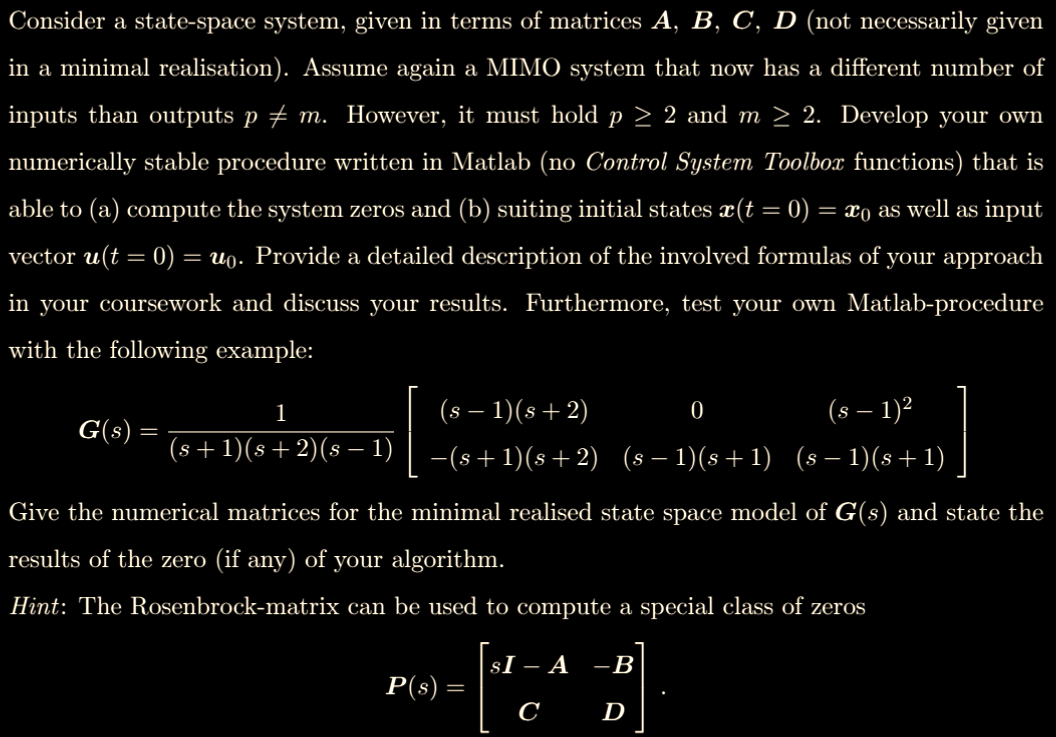

In [ ]:
clear all;
s = tf('s');
input = 5; output = 4;
sys = rss(2, output, input);
A = sys.A; B = sys.B; C = sys.C; D = sys.D;

In [ ]:
Ge = ss2tf(A, B, C, D, 1); size(Ge)

% Ge(4,5)
rank(Ge)

ans = 1×2 double
     4     3

ans = 3

In [ ]:
syms z;
G=C*inv(z*eye(size(A))-A)*B+D;
rank(G)
size(G)

ans = 4

ans = 1×2 double
     4     5

In [ ]:
function minor_val = detWithout(matrix, row_indices, col_indices)
    % Remove the specified rows and/or columns if provided
    subMatrix = matrix;
    if nargin > 1 && ~isempty(row_indices)
        subMatrix(row_indices, :) = []; % Remove the specified rows
    end
    if nargin > 2 && ~isempty(col_indices)
        subMatrix(:, col_indices) = []; % Remove the specified columns
    end
    
    % Calculate the determinant of the submatrix
    minor_val = det(subMatrix);
end

function minors = minors(matrix, order)
    % Calculate all minors of a given order
    [numRows, numCols] = size(matrix);
    if order > min(numRows, numCols)
        error('Order exceeds matrix dimensions');
    end
    if order == numRows && order ~= numCols
        colComb = nchoosek(1:numCols, order);
        minors = [];
        for j = 1:size(colComb, 1)
            minorMatrix = matrix(:, colComb(j, :));
            minorDet = det(minorMatrix);
            minors = [minors; minorDet];
        end
        return;
    end
    if order == numCols && order ~= numRows
        rowComb = nchoosek(1:numRows, order);
        minors = [];
        for i = 1:size(rowComb, 1)
            minorMatrix = matrix(rowComb(i, :), :);
            minorDet = det(minorMatrix);
            minors = [minors; minorDet];
        end
        return;
    end
    if order ~= numRows && order ~= numCols
        display("I have no idea to handle this case") % #TODO lookup commerical implementations
        return;
    end
end

% z = tf('z');
% G=C*inv(z*eye(size(A))-A)*B+D

mnrs = minors(G, 4);
% % rowComb
% size(G)
% size(mnrs)
% find least common multiple of denominators of minors


% Extract denominators of the minors
denominators = arrayfun(@(x) denom(x), mnrs, 'UniformOutput', false);

% Compute the least common denominator
lcd = denominators{1};
for i = 2:length(denominators)
    lcd = lcm(lcd, denominators{i});
end

disp('Least common denominator:');
disp(lcd);
% d = det([G(1,1), G(1,2); G(2,1), G(2,2)]);

Unrecognized function or variable 'denom'.

Error in Notebook>@(x)denom(x) (line 59)
denominators = arrayfun(@(x) denom(x), mnrs, 'UniformOutput', false);
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [ ]:
z = tf('z');

In [ ]:
d = simplify(d)

2.1.3 Perturbation and Internal Stability

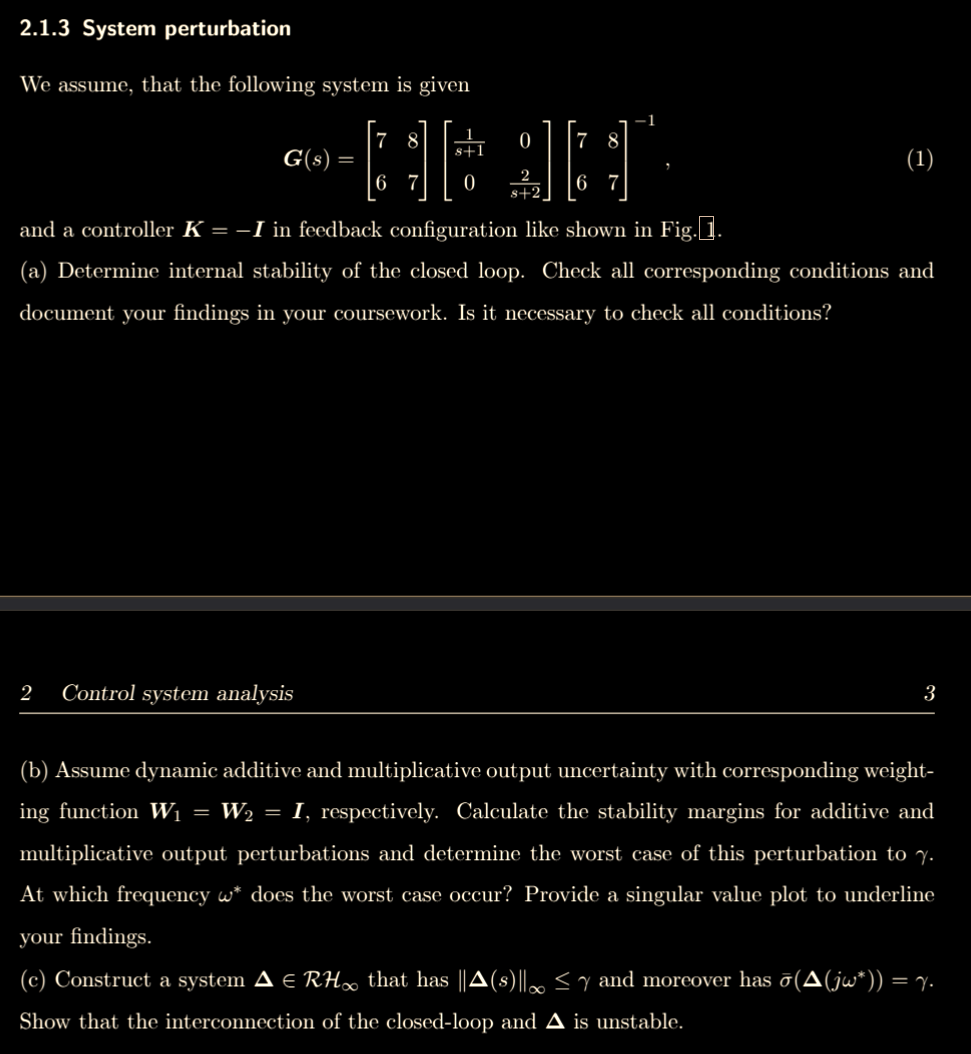


In [3]:
s = tf('s');
l = [7 8; 6 7];
m = [1/(s+1) 0; 0 2/(s+2)];
G = l*m*inv(l);
K = -eye(2);

In [ ]:
% (a)
CL11 = inv(eye(2)-K*G);
% pole(CL11) 
CL12 = K*inv(eye(2)-G*K);
% pole(CL12)
CL21 = G*inv(eye(2)-K*G);
% pole(CL21)
CL22 = inv(eye(2)-G*K);
pole(minreal(CL22))

ans = 
  -4.0000 + 0.0000i
  -2.0000 + 0.0000i
  -2.0000 - 0.0000i
  -4.0000 + 0.0000i
  -2.0000 + 0.0000i
  -2.0000 - 0.0000i
  -4.0000 + 0.0000i
  -2.0000 + 0.0000i
  -2.0000 + 0.0000i
  -4.0000 + 0.0000i
  -2.0000 + 0.0000i
  -2.0000 + 0.0000i

In [34]:
% Determine closed loop internal stability
CL = G*inv(eye(2) - G*K);
CL_poles = pole(CL);
disp('Closed-loop poles are:');
% disp(CL_poles);
if all(real(CL_poles) < 0)
    disp('The closed-loop system is internally stable.');
else
    disp('The closed-loop system is not internally stable.');
end

Closed-loop poles are:
The closed-loop system is internally stable.


a is done, but all expressions are not required coz K=-I and GK and KG are same.

In [4]:
% (b)

W1 = eye(2);
W2 = eye(2);
L = minreal(G*K);

In [5]:
I2 = eye(2);
S = minreal( inv(I2 + L) );
T = minreal( L * inv(I2 + L) ); 

In [7]:
M_mult = minreal(W2 * T);
M_add  = minreal(W1 * K * S);

In [ ]:
[M_add_inf,omega_add] = norm(M_add, inf)
[M_mult_inf,omega_mult] = norm(M_mult, inf)

M_add_inf = 3.6638e+16

omega_add = 0

M_mult_inf = 3.6638e+16

omega_mult = 0

In [45]:
gamma_add = 1/M_add_inf
gamma_mult = 1/M_mult_inf

gamma_add = 2.7294e-17

gamma_mult = 2.7294e-17

In [17]:
loop = feedback(M_mult*K, eye(2));

In [19]:
robstab(loop)

ans = struct with fields:
           LowerBound: 0
           UpperBound: 0
    CriticalFrequency: NaN

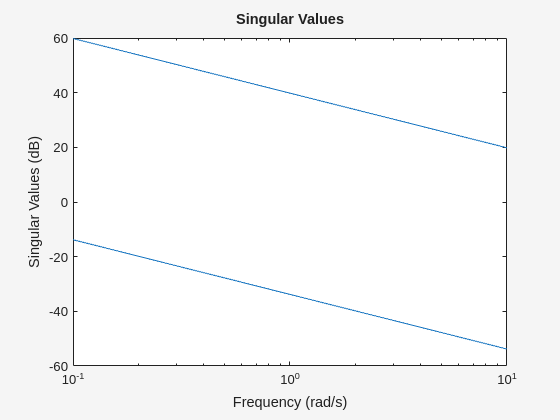

In [23]:
% singular values of M_mult
sigma(M_mult)

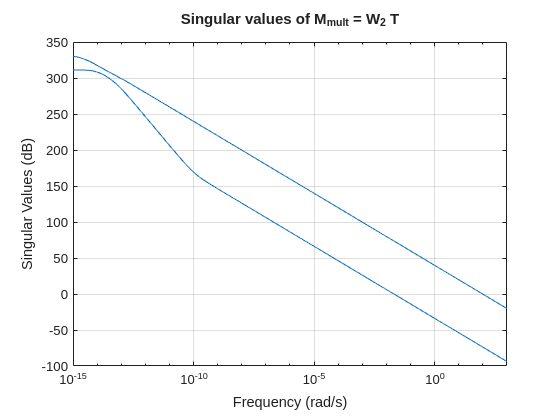

In [ ]:
w = logspace(-15, 3, 2000);
figure; sigma(T, w); grid on;
title('Singular values of M_{mult} = W_2 T');

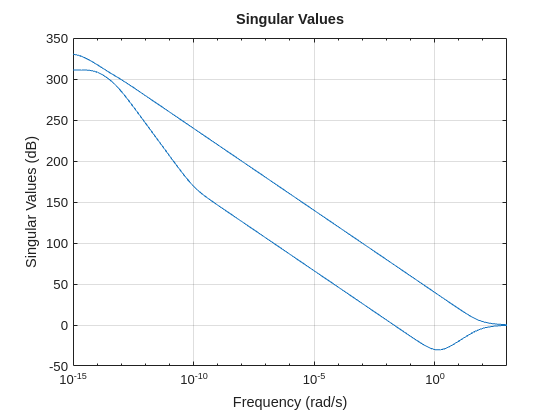

In [29]:
figure; sigma(M_add, w); grid on;

In [40]:
% (c)

[U,Sig,V]=svd(freqresp(M_mult, omega_mult));

In [43]:
alpha = 1;                          % any positive number
a = (s - alpha)/(s + alpha);

In [ ]:
Delta = gamma * a * (V*U');